# Data Collection and Pre-processing

## Introduction

Three separate datasets were obtained from online sources for this analysis: historical S&P 500 price data from Yahoo Finance, sector classifications from Wikipedia, and S&P 500 component weights from Slickcharts.

In [5]:
# Review the S&P 500 full dataset

import pandas as pd
full_data = pd.read_csv("../data/sp500_full.csv")
full_data.head()


,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector
0,2020-11-23,121.100960,121.601663,120.621121,120.836705,2468903,MMM,3M,Industrials
1,2020-11-24,123.145515,123.242882,121.629496,121.699044,3690856,MMM,3M,Industrials
2,2020-11-25,123.173325,123.326316,122.011972,122.978605,2454431,MMM,3M,Industrials
3,2020-11-27,123.013412,124.918872,122.095450,123.660153,1515452,MMM,3M,Industrials
4,2020-11-30,120.120453,122.394488,120.099589,122.234542,7344995,MMM,3M,Industrials


In [6]:
# Review the S&P 500 sectors dataset

import pandas as pd
sectors_df = pd.read_csv("../data/sp500_sectors.csv")
sectors_df.head()

,Symbol,Security,Sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology


In [7]:
# Review the S&P 500 weights dataset

import pandas as pd
weights_df = pd.read_csv("../data/sp500_weights.csv")
weights_df.head()

,#,Company,Symbol,Weight,Price,Chg,% Chg
0,1,Nvidia,NVDA,0.0731,178.88,-1.76,-0.0097
1,2,Apple Inc.,AAPL,0.0674,271.49,5.24,-0.0197
2,3,Microsoft,MSFT,0.0590,472.12,-6.31,-0.0132
3,4,Amazon,AMZN,0.0396,220.69,3.55,-0.0163
4,5,Alphabet Inc. (Class A),GOOGL,0.0315,299.66,10.21,-0.0353


In [8]:
# Merge sectors_df and weights_df on 'Symbol' to create sp500_wgts_sectors.csv

import pandas as pd

# Keep only Symbol and Weight columns from weights_df
weights_df = weights_df[['Symbol', 'Weight']]

# Fix symbol format in weights_df (BRK.B -> BRK-B to match sectors format)
weights_df['Symbol'] = weights_df['Symbol'].str.replace('.', '-', regex=False)

# Merge on Symbol
merged_df = sectors_df.merge(weights_df, on='Symbol', how='left')

# Save to new CSV
merged_df.to_csv('../data/sp500_wgts_sectors.csv', index=False)

print(f"Merged data saved to data/sp500_wgts_sectors.csv")
print(f"Rows with weights: {merged_df['Weight'].notna().sum()}")
print(f"Rows without weights: {merged_df['Weight'].isna().sum()}")


Merged data saved to data/sp500_wgts_sectors.csv
Rows with weights: 503
Rows without weights: 0


In [9]:
# Display the top 5 rows with the highest weights
merged_df.sort_values(by='Weight', ascending=False).head()

,Symbol,Security,Sector,Weight
344,NVDA,Nvidia,Information Technology,0.0731
38,AAPL,Apple Inc.,Information Technology,0.0674
314,MSFT,Microsoft,Information Technology,0.0590
22,AMZN,Amazon,Consumer Discretionary,0.0396
19,GOOGL,Alphabet Inc. (Class A),Communication Services,0.0315


In [10]:
# Create a summary table of sector counts and total weights
sector_summary = merged_df.groupby('Sector').agg(
    Company_count=('Symbol', 'count'),
    Total_weight=('Weight', 'sum')
).reset_index().sort_values(by='Total_weight', ascending=False)

sector_summary

,Sector,Company_count,Total_weight
7,Information Technology,69,0.3315
4,Financials,75,0.1334
0,Communication Services,24,0.1135
1,Consumer Discretionary,49,0.1046
5,Health Care,60,0.0969
6,Industrials,79,0.0789
2,Consumer Staples,37,0.0550
3,Energy,22,0.0281
10,Utilities,31,0.0230
9,Real Estate,31,0.0184


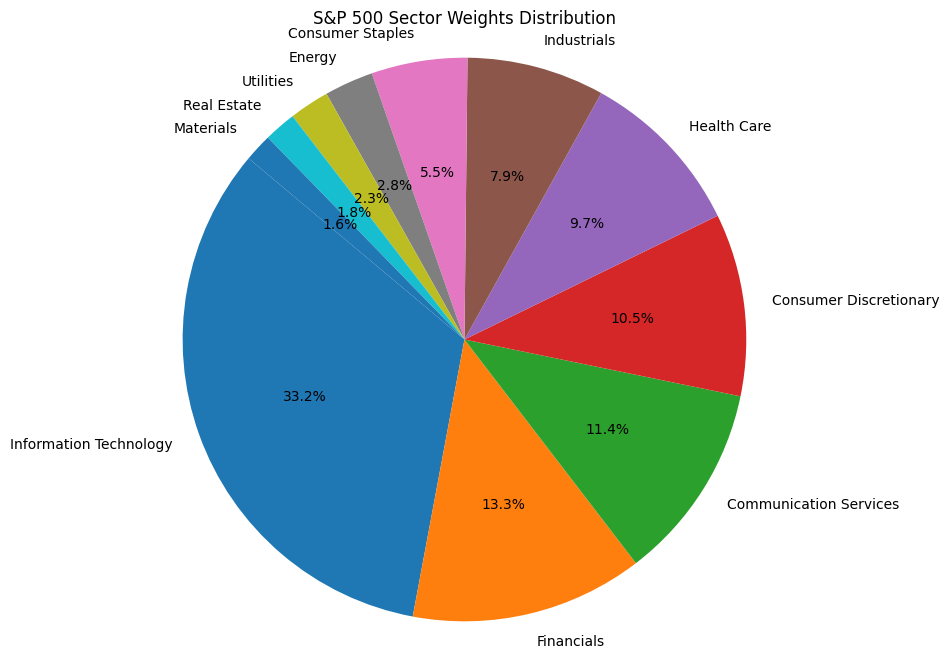

In [11]:
# Visualize sector weight distribution with a pie chart
import matplotlib.pyplot as plt

# Pie chart of total weights by sector
sector_weights = merged_df.groupby('Sector')['Weight'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,8))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', startangle=140)
plt.title('S&P 500 Sector Weights Distribution')
plt.axis('equal')
plt.show()

In [12]:
# Create a list of top 3 companies by weight in each sector

top3_by_sector = (
    merged_df.sort_values(['Sector', 'Weight'], ascending=[True, False])
             .groupby('Sector')
             .head(3)
             .reset_index(drop=True)
)

top3_by_sector

,Symbol,Security,Sector,Weight
0,GOOGL,Alphabet Inc. (Class A),Communication Services,0.0315
1,GOOG,Alphabet Inc. (Class C),Communication Services,0.0293
2,META,Meta Platforms,Communication Services,0.0252
3,AMZN,Amazon,Consumer Discretionary,0.0396
4,TSLA,"Tesla, Inc.",Consumer Discretionary,0.0219
5,HD,Home Depot (The),Consumer Discretionary,0.0057
6,WMT,Walmart,Consumer Staples,0.0141
7,COST,Costco,Consumer Staples,0.0067
8,PG,Procter & Gamble,Consumer Staples,0.0059
9,XOM,ExxonMobil,Energy,0.0083


In [13]:
# Use the top3_by_sector as a filter to get a subset of sp500_full.csv

sp500_subset = full_data[full_data['Symbol'].isin(top3_by_sector['Symbol'])]
sp500_subset.head()

,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector
3765,2020-11-23,84.081802,84.559074,83.168406,83.884313,7541500,ABBV,AbbVie,Health Care
3766,2020-11-24,85.546516,86.254193,84.410945,84.657805,9322200,ABBV,AbbVie,Health Care
3767,2020-11-25,85.744026,85.957977,85.077496,85.431334,6368100,ABBV,AbbVie,Health Care
3768,2020-11-27,86.311798,87.060621,85.826302,86.385860,4418800,ABBV,AbbVie,Health Care
3769,2020-11-30,86.056725,86.747940,85.291446,86.501080,20726500,ABBV,AbbVie,Health Care


In [15]:
# Save the subset to a new CSV file

sp500_subset.to_csv('../data/sp500_subset.csv', index=False)
print(f"Subset data saved to data/sp500_subset.csv")

Subset data saved to data/sp500_subset.csv
